In [18]:
%pip install pandas openpyxl
%pip install dash plotly pandas
%pip install pandas dash plotly geopy openpyxl
%pip install requests
%pip install osmnx geopandas shapely geopy
%pip install dash plotly pandas geopandas geopy openpyxl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [9]:
# Hannah

# Load data
df = pd.read_excel('FinalSheet.xlsx', engine='openpyxl')

# Strip whitespace and handle basic text cleaning
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Convert dates to datetime objects
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Clean numeric columns (removing commas, etc.)
df['Grant Amount'] = df['Grant Amount'].astype(str).str.replace(',', '')
df['Grant Amount'] = pd.to_numeric(df['Grant Amount'], errors='coerce')

# Replace placeholders with proper Null values
df.replace(['N/A', 'nan', 'None'], pd.NA, inplace=True)

# Show the first 5 rows
df.head()

,Year,Date,Grant Amount,Project Category 1,Project Category 2,Location,Organization
0,2015,2015-03-04,4000.0,Education/Competition,NaN,Kamin Science Center,Kamin Science Center
1,2015,2015-05-06,50000.0,Tree Planting,NaN,"Lawrenceville, Chateau, Neville Island",Tree Pittsburgh
2,2015,2015-05-06,225000.0,Education/Competition,NaN,Allegheny County,ACHD
3,2015,2015-07-08,337600.0,Public Health/Medicine,NaN,Northgate School District,Healthy Homes Program
4,2015,2015-09-02,400000.0,Emission Reduction,Diesel Reduction/Electrification,"CCAC Allegheny Campus, CCAC North Campus, CCAC...",Community College of Allegheny County


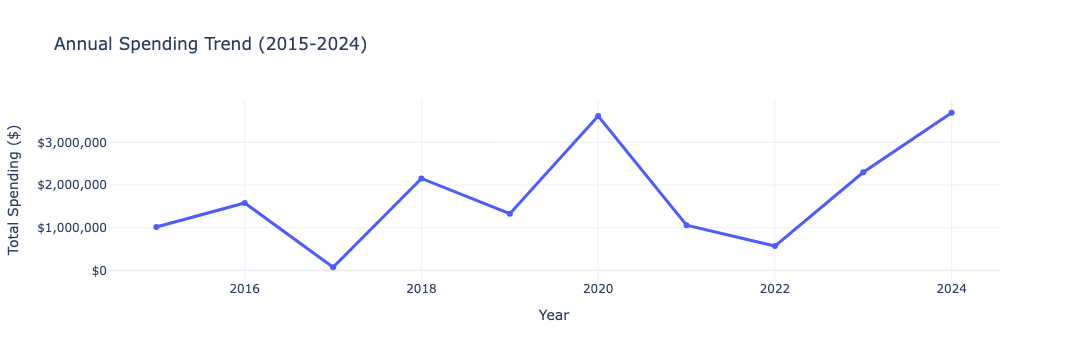

In [3]:
# Spending by Year

# Group by Year and sum the Grant Amount
df_yearly = df.groupby('Year')['Grant Amount'].sum().reset_index()

# Check the transformed data
# print(df_yearly.head())

# Create the Line Chart
fig = px.line(df_yearly, 
            x='Year', 
            y='Grant Amount', 
            title='Annual Spending Trend (2015-2024)',
            markers=True, # Adds dots to the line for easier hovering
            template='plotly_white')

# Enhance the Interactivity & Look
fig.update_traces(line_color="#4d5cfd", line_width=3) # Custom line color
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Spending ($)",
    hovermode="x unified", # Shows all data for that year in one tooltip
    yaxis=dict(
        title="Grant Amount",
        tickprefix="$",    # Adds $ to the start of every number
        tickformat=",",    # Adds commas (e.g., 1,000,000)
    )
)

fig.show()

# Export for Wix
html_snippet = fig.to_html(full_html=False, include_plotlyjs='cdn')
# print(html_snippet)

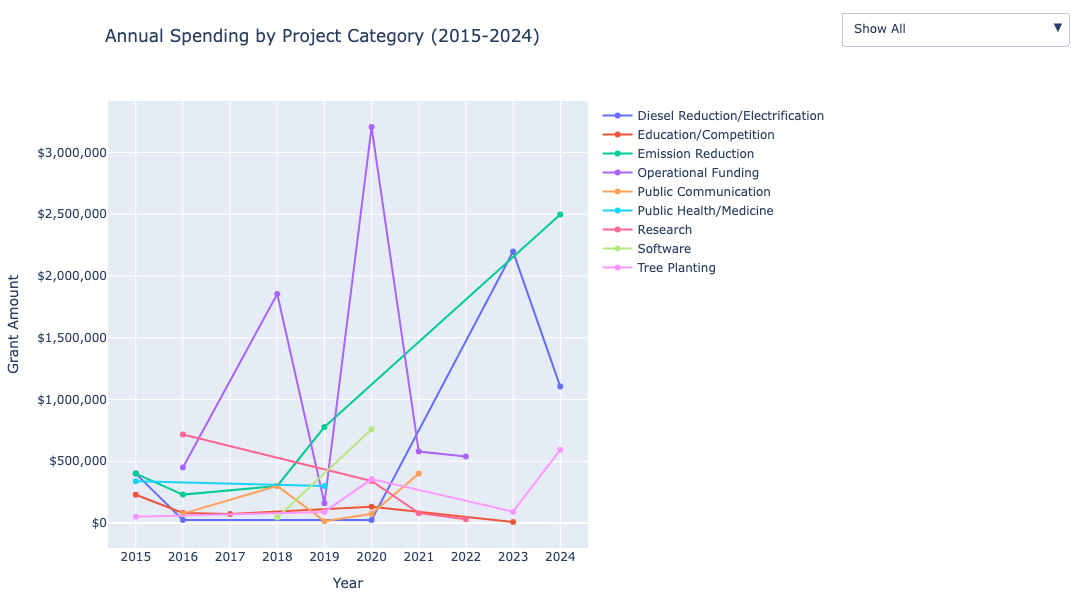

In [13]:
# TRANSFORM DATA: Handle both Project Category 1 and 2
# We create two dataframes and stack them to ensure "Double Counting"
df1 = df[['Year', 'Grant Amount', 'Project Category 1']].rename(columns={'Project Category 1': 'Project Category'})
df2 = df[['Year', 'Grant Amount', 'Project Category 2']].rename(columns={'Project Category 2': 'Project Category'})

# Combine them and remove rows where the category is empty (mostly from Category 2)
df_combined = pd.concat([df1, df2]).dropna(subset=['Project Category'])

#GROUP DATA: Sum spending by Year and Category
df_grouped = df_combined.groupby(['Year', 'Project Category'])['Grant Amount'].sum().reset_index()

# Get the unique list of categories for the loop and dropdown
categories = sorted(df_grouped['Project Category'].unique())

fig = go.Figure()

# Add a line for each category
for cat in categories:
    temp_df = df_grouped[df_grouped['Project Category'] == cat]
    fig.add_trace(
        go.Scatter(
            x=temp_df['Year'], 
            y=temp_df['Grant Amount'], 
            name=cat, 
            mode='lines+markers', 
            visible=True
        )
    )

# --- CREATE THE DROPDOWN & LAYOUT ---
fig.update_layout(
    updatemenus=[
        {
            "buttons": [
                {
                    "label": "Show All",
                    "method": "update",
                    "args": [{"visible": [True] * len(categories)}, {"title": "All Project Spending"}]
                },
                *[
                    {
                        "label": cat,
                        "method": "update",
                        "args": [
                            {"visible": [c == cat for c in categories]},
                            {"title": f"Spending: {cat}"}
                        ]
                    } for cat in categories
                ]
            ],
            "direction": "down",
            "showactive": True,
            "x": 2.0,           # 1.0 is the far right edge of the chart area
            "xanchor": "right", # Aligns the right side of the menu to the x-coordinate
            "y": 1.2            # Keeps it above the plot
        }
    ],
    width=1000,
    height=600,
    autosize=False,
    margin=dict(l=50, r=50, t=100, b=50),
    xaxis=dict(title="Year", tickmode='linear'), 
    yaxis=dict(
        title="Grant Amount",
        tickprefix="$",    
        tickformat=",",    
    ),
    title={
            'text': "Annual Spending by Project Category (2015-2024)",
            'y': 0.95,           
            'x': 0.5,            
            'xanchor': 'right', 
            'yanchor': 'top'
    },
    hovermode="x unified"
)

fig.show()

# Export for Wix (or any web embedding)
html_snippet = fig.to_html(full_html=False, include_plotlyjs='cdn')
# print(html_snippet) 

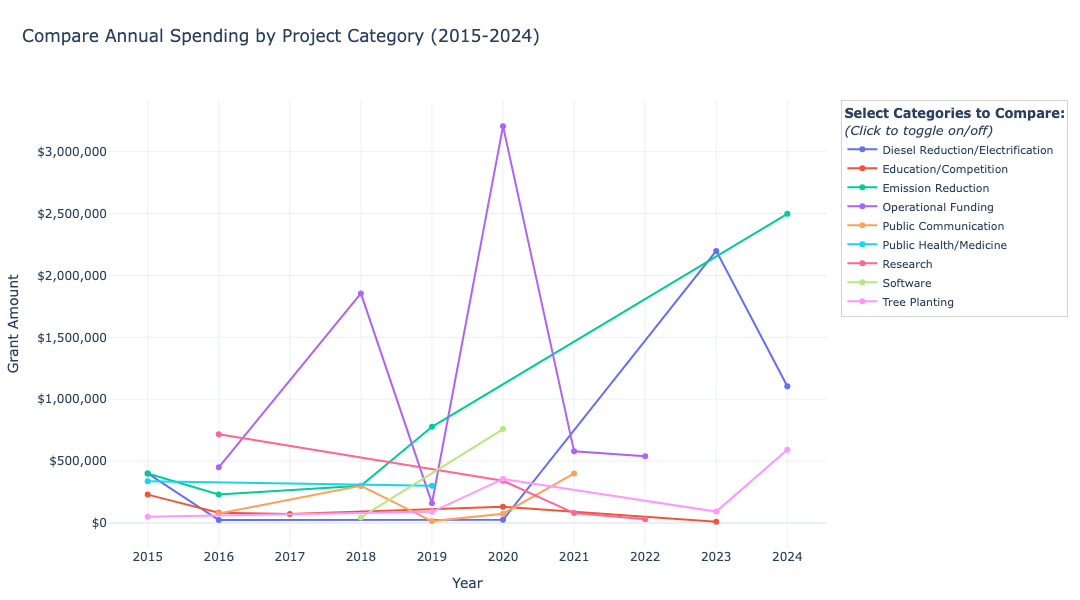

In [ ]:
# 2. TRANSFORM DATA: Handle both Project Category 1 and 2
df1 = df[['Year', 'Grant Amount', 'Project Category 1']].rename(columns={'Project Category 1': 'Project Category'})
df2 = df[['Year', 'Grant Amount', 'Project Category 2']].rename(columns={'Project Category 2': 'Project Category'})

# Combine and remove rows where the category is empty
df_combined = pd.concat([df1, df2]).dropna(subset=['Project Category'])

# 3. GROUP DATA: Sum spending by Year and Category
df_grouped = df_combined.groupby(['Year', 'Project Category'])['Grant Amount'].sum().reset_index()

# Get the list of unique categories
categories = sorted(df_grouped['Project Category'].unique())

# --- CREATE THE FIGURE ---
fig = go.Figure()

# Add a trace for each category (this makes each one toggleable)
for cat in categories:
    temp_df = df_grouped[df_grouped['Project Category'] == cat]
    fig.add_trace(
        go.Scatter(
            x=temp_df['Year'], 
            y=temp_df['Grant Amount'], 
            name=cat, 
            mode='lines+markers',
            visible=True, # All visible by default
            hovertemplate="<b>" + cat + "</b><br>Amount: $%{y:,.0f}<extra></extra>"
        )
    )

# --- CONFIGURE LAYOUT FOR COMPARISON ---
fig.update_layout(
    width=1100, # Widened slightly to make room for the legend
    height=600,
    autosize=False,
    margin=dict(l=50, r=250, t=100, b=50), # Large right margin for the legend "menu"
    xaxis=dict(title="Year", tickmode='linear'), 
    yaxis=dict(
        title="Grant Amount",
        tickprefix="$",    
        tickformat=",",    
    ),
    title={
            'text': "Comparative Annual Spending by Project Category (2015-2024)",
            'y': 0.95, 
            'x': 0.5, 
            'xanchor': 'right', 
            'yanchor': 'top'
    },
    # Legend settings to make it act like a checkbox menu
    legend=dict(
        title="<b>Select Categories to Compare:</b><br><i>(Click to toggle on/off)</i>",
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02, # Position it to the right of the plot
        itemclick="toggle", # Toggles visibility like a checkbox
        itemdoubleclick="toggleothers", # Double-click to see ONLY that category
        font=dict(size=11),
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="lightgrey",
        borderwidth=1
    ),
    template="plotly_white",
    hovermode="x unified" # Shows all active categories in one hover window for comparison
)

fig.show()

# Export for Wix (Copy the snippet below if needed)
# html_snippet = fig.to_html(full_html=False, include_plotlyjs='cdn')
# print(html_snippet)

In [24]:
# TRANSFORM DATA: Handle both Category 1 and Category 2
# We stack them to ensure a project with two categories appears in both
df1 = df[['Year', 'Grant Amount', 'Project Category 1']].rename(columns={'Project Category 1': 'Category'})
df2 = df[['Year', 'Grant Amount', 'Project Category 2']].rename(columns={'Project Category 2': 'Category'})
df_combined = pd.concat([df1, df2]).dropna(subset=['Category'])

# GROUP DATA: Sum spending by Year and Category
df_grouped = df_combined.groupby(['Year', 'Category'])['Grant Amount'].sum().reset_index()

# Get the list of all years and categories
all_years = sorted(df_grouped['Year'].unique())
all_cats = sorted(df_grouped['Category'].unique())

colors_palette = px.colors.qualitative.Plotly + px.colors.qualitative.Safe
category_colors = {cat: colors_palette[i % len(colors_palette)] for i, cat in enumerate(all_cats)}

# CREATE THE FIGURE
fig = go.Figure()

# Add a separate Bar trace for each year
for year in all_years:
    # Filter for the year
    year_data = df_grouped[df_grouped['Year'] == year].copy()
    
    # --- KEY CHANGE: Remove categories with 0 or No spending in this specific year ---
    year_data = year_data[year_data['Grant Amount'] > 0]
    
    # Sort by amount descending to make the bar chart look neat
    year_data = year_data.sort_values(by='Grant Amount', ascending=False)

    # Generate colors based on the categories actually present this year
    current_bar_colors = [category_colors[cat] for cat in year_data['Category']]
    fig.add_trace(
        go.Bar(
            x=year_data['Category'],
            y=year_data['Grant Amount'],
            name=str(year),
            visible=(year == all_years[0]), # Show first year by default
            marker_color=current_bar_colors, # Assign the list of colors
            hovertemplate="Category: %{x}<br>Total: %{y:$,.0f}<extra></extra>"
        )
    )
# CREATE DROPDOWN BUTTONS
dropdown_buttons = []

for i, year in enumerate(all_years):
    # Only show the trace corresponding to the selected year
    visibility = [False] * len(all_years)
    visibility[i] = True

    dropdown_buttons.append(dict(
        label=f"Year: {year}",
        method="update",
        args=[{"visible": visibility},
            {"title": f"Spending by Project Category in {year}"}]
    ))

# UPDATE LAYOUT
fig.update_layout(
updatemenus=[dict(
        active=0,
        buttons=dropdown_buttons,
        direction="down",
        x=1.1,
        xanchor="left",
        y=1.2,
        yanchor="top",
        showactive=True
    )],
    xaxis=dict(title="Project Category", tickangle=45),
    yaxis=dict(title="Total Grant Amount ($)", tickprefix="$", tickformat=","),
    title={
        'text': f"Spending by Project Category in {all_years[0]}",
        'x': 0.05,
        'xanchor': 'left',
        'y': 0.95
        },
    template="plotly_white",
    height=600,
    width=1000,
    margin=dict(t=120) # Space for the dropdown and title
)

fig.show()

# Export for Wix/Web embedding
# html_snippet = fig.to_html(full_html=False, include_plotlyjs='cdn')
# print(html_snippet)

In [ ]:
# Abby
import pandas as pd
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load Excel file
df = pd.read_excel('CAF_DS.xlsx')

# Clean Grant Amount
df['Grant Amount'] = (
    df['Grant Amount']
    .astype(str)
    .str.replace(r'[\$,\s]', '', regex=True)
    .astype(float)
)

# Clean category column
df['Project Category 1'] = df['Project Category 1'].str.strip()

# Aggregate data
cat_spend = (
    df.groupby('Project Category 1')['Grant Amount']
    .sum()
    .reset_index()
    .sort_values('Grant Amount', ascending=False)
)

# --- PIE CHART ---
fig = px.pie(
    cat_spend,
    names='Project Category 1',
    values='Grant Amount',
    title='Grant Spending Distribution by Category',
    hole=0.4  # donut style
)

fig.update_traces(
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>$%{value:,.0f}<br>%{percent}'
)

fig.update_layout(height=500)

fig.show()

In [ ]:
import sys
!{sys.executable} -m pip install plotly

In [22]:
# Neha -- Grant Funding Over Time with formatted dates and white background

import pandas as pd
from dash import Dash, dcc, html, Input, Output, State, callback_context
import plotly.express as px

# Load data
df = pd.read_excel("FinalSheet.xlsx", sheet_name="FinalSheet")

# Clean columns
df.columns = df.columns.str.strip()
df["Grant Amount"] = df["Grant Amount"].replace(r'[\$,]', '', regex=True).astype(float)
df["Project Category 2"] = df["Project Category 2"].replace("N/A", pd.NA)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Get unique categories and years
categories = pd.unique(pd.concat([df["Project Category 1"], df["Project Category 2"]]).dropna())
years = sorted(df["Year"].dropna().unique())

# Helper function to format date with ordinal
def format_date(dt):
    if pd.isna(dt):
        return ""
    day = dt.day
    if 11 <= day <= 13:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(day % 10, "th")
    return dt.strftime(f"%B {day}{suffix}, %Y")  # e.g., April 4th, 2026

app = Dash(__name__)

app.layout = html.Div([

    html.H2("Grant Funding Over Time"),

    # CATEGORY DROPDOWN
    html.Div([
        html.Label("Select Categories"),
        dcc.Dropdown(
            id='category_selector',
            options=[{"label": c, "value": c} for c in categories],
            value=list(categories),
            multi=True,
            placeholder="Select Project Categories"
        )
    ], style={"margin-bottom": "20px"}),

    # TIME GRANULARITY RADIO
    html.Div([
        html.Label("Select Time Granularity"),
        dcc.RadioItems(
            id='date_mode',
            options=[
                {"label": "Year Only", "value": "year"},
                {"label": "Month by Month", "value": "month"}
            ],
            value="year",
            labelStyle={"display": "inline-block", "margin-right": "20px"}
        )
    ], style={"margin-bottom": "20px"}),

    # YEAR DROPDOWN
    html.Div([
        html.Label("Select Years"),
        dcc.Dropdown(
            id='year_selector',
            options=[{"label": y, "value": y} for y in years],
            value=years,
            multi=True,
            placeholder="Select Years"
        )
    ], style={"margin-bottom": "20px"}),

    # GRAPH
    dcc.Graph(id='grant_graph'),

    # MODAL FOR DETAILED INFO
    html.Div([
        html.Div(id='modal_content', style={
            'backgroundColor': 'white',
            'padding': '20px',
            'borderRadius': '5px',
            'width': '80%',
            'margin': 'auto',
            'maxHeight': '80vh',
            'overflowY': 'auto'
        }),
        html.Button("Close", id="close_modal", style={'margin-top': '10px'})
    ], id='modal', style={
        'display': 'none',
        'position': 'fixed',
        'top': 0,
        'left': 0,
        'width': '100%',
        'height': '100%',
        'backgroundColor': 'rgba(0,0,0,0.5)',
        'paddingTop': '50px'
    })

])

@app.callback(
    Output("grant_graph", "figure"),
    Input("category_selector", "value"),
    Input("year_selector", "value"),
    Input("date_mode", "value")
)
def update_graph(selected_categories, selected_years, date_mode):
    filtered = df.copy()
    filtered = filtered[
        filtered["Project Category 1"].isin(selected_categories) |
        filtered["Project Category 2"].isin(selected_categories)
    ]
    filtered = filtered[filtered["Year"].isin(selected_years)]

    max_hover_projects = 5  # show up to 5 projects in hover, rest "+ X more"

    if date_mode == "year":
        grouped = filtered.groupby("Year")
        x_values = sorted(filtered["Year"].unique())
        hover_texts = []
        for x in x_values:
            temp = filtered[filtered["Year"] == x]
            hover_text = ""
            for i, (_, row) in enumerate(temp.iterrows()):
                if i >= max_hover_projects:
                    break
                cats = ", ".join([row["Project Category 1"]] + ([row["Project Category 2"]] if pd.notna(row["Project Category 2"]) else []))
                hover_text += f"{cats}<br>Date: {format_date(row['Date'])}<br>Amount: ${row['Grant Amount']:,}<br><br>"
            remaining = len(temp) - max_hover_projects
            if remaining > 0:
                hover_text += f"+ {remaining} more… Click for details"
            else:
                hover_text += "Click for details"
            hover_texts.append(hover_text)
        fig = px.line(
            x=x_values,
            y=grouped["Grant Amount"].sum(),
            markers=True
        )
        fig.update_traces(hovertemplate="%{text}", text=hover_texts)
    else:
        filtered = filtered.dropna(subset=["Date"])
        filtered["Month"] = filtered["Date"].dt.to_period("M").dt.to_timestamp()
        grouped = filtered.groupby("Month")
        x_values = sorted(filtered["Month"].unique())
        hover_texts = []
        for x in x_values:
            temp = filtered[filtered["Month"] == x]
            hover_text = ""
            for i, (_, row) in enumerate(temp.iterrows()):
                if i >= max_hover_projects:
                    break
                cats = ", ".join([row["Project Category 1"]] + ([row["Project Category 2"]] if pd.notna(row["Project Category 2"]) else []))
                hover_text += f"{cats}<br>Date: {format_date(row['Date'])}<br>Amount: ${row['Grant Amount']:,}<br><br>"
            remaining = len(temp) - max_hover_projects
            if remaining > 0:
                hover_text += f"+ {remaining} more… Click for details"
            else:
                hover_text += "Click for details"
            hover_texts.append(hover_text)
        fig = px.line(
            x=x_values,
            y=grouped["Grant Amount"].sum(),
            markers=True
        )
        fig.update_traces(hovertemplate="%{text}", text=hover_texts)

    # Clean white background style
    fig.update_layout(
        title="Grant Money Allocated Over Time",
        xaxis_title="Year",
        yaxis_title="Grant Amount",
        plot_bgcolor='white',        # Chart background
        paper_bgcolor='white',       # Outer background
        font=dict(color='black'),    # Text color
        xaxis=dict(showgrid=True, gridcolor='lightgray'),
        yaxis=dict(showgrid=True, gridcolor='lightgray')
    )
    return fig

# CALLBACK TO SHOW MODAL ON POINT CLICK
@app.callback(
    Output("modal", "style"),
    Output("modal_content", "children"),
    Input("grant_graph", "clickData"),
    Input("close_modal", "n_clicks"),
    State("date_mode", "value"),
    prevent_initial_call=True
)
def display_modal(clickData, close_clicks, date_mode):
    ctx = callback_context
    if not ctx.triggered:
        raise dash.exceptions.PreventUpdate

    trigger_id = ctx.triggered[0]["prop_id"].split(".")[0]

    if trigger_id == "close_modal":
        return {'display': 'none'}, []

    if clickData is None:
        raise dash.exceptions.PreventUpdate

    point_x = clickData["points"][0]["x"]

    # Filter projects for that point
    if date_mode == "year":
        temp = df[df["Year"] == int(point_x)]
    else:
        temp = df[df["Date"].dt.to_period("M").dt.to_timestamp() == pd.to_datetime(point_x)]

    children = []
    for _, row in temp.iterrows():
        cats = ", ".join([row["Project Category 1"]] + ([row["Project Category 2"]] if pd.notna(row["Project Category 2"]) else []))
        children.append(html.Div([
            html.H4(f"{cats} - ${row['Grant Amount']:,}"),
            html.P(f"Date Allocated: {format_date(row['Date'])}"),
            html.P(f"Organization: {row.get('Organization','')}"),
            html.P(f"Location: {row.get('Location','')}"),
            html.P(f"Project Description: {row.get('Project Description','')}"),
            html.Hr()
        ]))
    return {'display': 'block', 'position': 'fixed', 'top': 0, 'left': 0,
            'width': '100%', 'height': '100%', 'backgroundColor': 'rgba(0,0,0,0.5)',
            'paddingTop': '50px'}, children

if __name__ == "__main__":
    app.run(debug=True)

In [26]:
# Neha Map (1)
"""
Grant Map Explorer
==================
• Filters by Category, Year, Location
• Click a project → map shows boundary polygon, multi-polygon, street line, or pin
• Boundaries fetched automatically from OpenStreetMap (cached to disk)
• Points use hardcoded coordinates for accuracy
"""

import json, os, time
import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State
from dash.dependencies import ALL
import osmnx as ox
from geopy.geocoders import Nominatim

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
EXCEL_FILE  = "FinalSheet.xlsx"
CACHE_FILE  = "geo_cache.json"
SEARCH_AREA = "Allegheny County, Pennsylvania, USA"

# ─────────────────────────────────────────
# GEOMETRY CACHE  (avoids repeated API hits)
# ─────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        geo_cache = json.load(f)
else:
    geo_cache = {}

def save_cache():
    with open(CACHE_FILE, "w") as f:
        json.dump(geo_cache, f)

# ─────────────────────────────────────────
# ★ HARDCODED POINT COORDINATES
#   Format: "Location string as it appears in Excel": (lat, lon)
#   The key must exactly match the Location column value.
# ─────────────────────────────────────────
HARDCODED_POINTS = {
    # ── Confirmed coordinates ──────────────────────────────────────────────
    "Kamin Science Center":              (40.44595221170012,  -80.01807791529143),
    "Allegheny County Parks Department": (40.4381181481758,   -79.99572308830757),

    # ── CCAC campuses (multi-point project — all 4 appear at once) ─────────
    # The Location column value in Excel for this row should be exactly:
    # "CCAC Allegheny Campus, CCAC North Campus, CCAC Boyce Campus, CCAC South Campus"
    # Each name below is the individual part after splitting on commas.
    "CCAC Allegheny Campus": (40.450014561047716, -80.01527415790444),
    "CCAC North Campus":     (40.565842422413404, -80.03973194513793),
    "CCAC Boyce Campus":     (40.45364252190304,  -79.75250943248656),
    "CCAC South Campus":     (40.33001404979938,  -79.92411611714877),

    # ── School districts (points) ──────────────────────────────────────────
    # The Location column value in Excel for the 5-district project should be exactly:
    # "Bethel Park School District, McKeesport Area School District, Woodland Hills School District, West Mifflin Area School District, South Fayette School District"
    "Northgate School District":          (40.495777718160255, -80.05926282607038),
    "Bethel Park School District":        (40.328249066249896, -80.04513493271227),
    "McKeesport Area School District":    (40.34342437366977,  -79.85199590329259),
    "Woodland Hills School District":     (40.42217331153984,  -79.86935535715494),
    "West Mifflin Area School District":  (40.3580980232183,   -79.90497169970247),
    "South Fayette School District":      (40.359316565474,    -80.17023893680236),

    # ── Monongahela Valley — placeholder center point ──────────────────────
    # ★ REPLACE with a more specific coordinate when ready.
    #   Current placeholder: approximate regional center near McKeesport/Duquesne.
    #   To update: right-click the desired spot in Google Maps → copy coordinates.
    "Monongahela Valley":                 (40.3388, -79.8672),

    # ── ADD YOUR OWN POINTS HERE ───────────────────────────────────────────
    # To find coordinates: open Google Maps, right-click a location, click the
    # lat/lon numbers at the top of the context menu to copy them.
    #
    # "Some Other Place Name": (LAT, LON),
}

# ─────────────────────────────────────────
# ★ OSM BOUNDARY LOCATIONS
#   These are fetched automatically from OpenStreetMap using osmnx.
#   The key is the individual place name (after splitting on commas).
#   The value is the exact search string to pass to OSM — tweak it if a
#   boundary comes back wrong (e.g. wrong state, wrong admin level).
#
#   HOW TO VERIFY: paste the query string into https://nominatim.openstreetmap.org/
#   and confirm the top result is the correct polygon before running the app.
# ─────────────────────────────────────────
OSM_BOUNDARY_QUERIES = {
    # ── Neighborhoods ─────────────────────────────────────────────────────
    "Lawrenceville":   "Lawrenceville, Pittsburgh, Pennsylvania, USA",
    "Chateau":         "Chateau, Pittsburgh, Pennsylvania, USA",
    "Neville Island":  "Neville Island, Pennsylvania, USA",

    # ── County ────────────────────────────────────────────────────────────
    "Allegheny County": "Allegheny County, Pennsylvania, USA",

    # ── Boroughs ──────────────────────────────────────────────────────────
    "Carnegie Borough":       "Carnegie, Pennsylvania, USA",
    "Churchill Borough":      "Churchill, Allegheny County, Pennsylvania, USA",
    "Swissvale Borough":      "Swissvale, Pennsylvania, USA",
    "West Mifflin Borough":   "West Mifflin, Pennsylvania, USA",
    "Wilkinsburg Borough":    "Wilkinsburg, Pennsylvania, USA",
    "Brackenridge Borough":   "Brackenridge, Pennsylvania, USA",
    "Pitcairn Borough":       "Pitcairn, Pennsylvania, USA",
    "Braddock Borough":       "Braddock, Pennsylvania, USA",
    "North Braddock Borough": "North Braddock, Pennsylvania, USA",
    "Rankin Borough":         "Rankin, Pennsylvania, USA",
    "East Pittsburgh Borough":"East Pittsburgh, Pennsylvania, USA",

    # ── Cities ────────────────────────────────────────────────────────────
    "Pittsburgh": "Pittsburgh, Pennsylvania, USA",

    # ── ADD YOUR OWN BOUNDARY LOCATIONS HERE ──────────────────────────────
    # "Some Borough": "Some Borough, Allegheny County, Pennsylvania, USA",
}

# ─────────────────────────────────────────
# ★ STREET LOCATIONS
#   Keys must match the individual part name after comma-splitting.
#   "osm_query" is passed to osmnx to fetch the actual road geometry.
#   "geocode_fallback" is used if osmnx can't find the road.
# ─────────────────────────────────────────
STREET_LOCATIONS = {
    "Corrigan Dr. in South Park": {
        "osm_query":        "Corrigan Drive, South Park Township, Allegheny County, Pennsylvania, USA",
        "geocode_fallback": "Corrigan Drive, South Park Township, PA",
    },

    # ── ADD YOUR OWN STREETS HERE ─────────────────────────────────────────
    # "Main St. in Braddock": {
    #     "osm_query":        "Main Street, Braddock, Pennsylvania, USA",
    #     "geocode_fallback": "Main Street, Braddock, PA",
    # },
}

# ─────────────────────────────────────────
# GEOMETRY RESOLUTION HELPERS
# ─────────────────────────────────────────
geolocator = Nominatim(user_agent="grant_map_explorer_v2")

def fetch_osm_polygon(osm_query: str):
    """Fetch a named boundary polygon from OSM via osmnx."""
    try:
        gdf = ox.geocode_to_gdf(osm_query)
        if gdf is not None and not gdf.empty:
            return gdf
    except Exception:
        pass
    return None

def fetch_street_geometry(osm_query: str):
    """Fetch road centerline geometry from OSM as a list of (lat, lon) pairs."""
    try:
        G = ox.graph_from_address(osm_query, dist=500, network_type="drive")
        # osmnx v2: graph_to_gdfs returns (nodes_gdf, edges_gdf) tuple
        _, edges = ox.graph_to_gdfs(G)
        coords = []
        for geom in edges.geometry:
            xs, ys = geom.xy
            coords += list(zip(ys, xs))   # (lat, lon)
        return coords
    except Exception:
        return []

def geocode_point(query: str):
    """Returns (lat, lon) via Nominatim or None."""
    try:
        loc = geolocator.geocode(query, timeout=10)
        if loc:
            return (loc.latitude, loc.longitude)
    except Exception:
        pass
    return None

def geometry_to_traces(geom, name: str, color: str):
    """Recursively convert a shapely geometry to Plotly Scattermapbox traces."""
    traces = []
    gtype = geom.geom_type
    if gtype == "Polygon":
        lons, lats = geom.exterior.xy
        fill_color = color + "30"   # ~19% opacity hex alpha
        traces.append(go.Scattermapbox(
            lon=list(lons), lat=list(lats),
            mode="lines", fill="toself",
            fillcolor=fill_color,
            line=dict(color=color, width=2.5),
            name=name, hoverinfo="name"
        ))
    elif gtype == "MultiPolygon":
        for poly in geom.geoms:
            traces += geometry_to_traces(poly, name, color)
    elif gtype in ("LineString", "MultiLineString"):
        geoms = [geom] if gtype == "LineString" else geom.geoms
        for line in geoms:
            lons, lats = line.xy
            traces.append(go.Scattermapbox(
                lon=list(lons), lat=list(lats),
                mode="lines", line=dict(color=color, width=4),
                name=name, hoverinfo="name"
            ))
    elif gtype == "Point":
        traces.append(go.Scattermapbox(
            lon=[geom.x], lat=[geom.y], mode="markers",
            marker=dict(size=14, color=color),
            name=name, hoverinfo="name"
        ))
    elif gtype == "GeometryCollection":
        for g in geom.geoms:
            traces += geometry_to_traces(g, name, color)
    return traces

PALETTE = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#6a4c93"]

def resolve_part(part: str, color: str):
    """
    Resolve a single location part to Plotly traces + a center (lat, lon).
    Priority: hardcoded point → street → OSM boundary → Nominatim fallback.
    """
    # 1. Hardcoded point
    if part in HARDCODED_POINTS:
        lat, lon = HARDCODED_POINTS[part]
        trace = go.Scattermapbox(
            lon=[lon], lat=[lat], mode="markers",
            marker=dict(size=16, color=color, symbol="circle"),
            name=part, hoverinfo="name"
        )
        return [trace], (lat, lon)

    # 2. Street
    if part in STREET_LOCATIONS:
        cfg = STREET_LOCATIONS[part]
        coords = fetch_street_geometry(cfg["osm_query"])
        if coords:
            lats = [c[0] for c in coords]
            lons = [c[1] for c in coords]
            trace = go.Scattermapbox(
                lon=lons, lat=lats, mode="lines",
                line=dict(color=color, width=5),
                name=part, hoverinfo="name"
            )
            center = (sum(lats) / len(lats), sum(lons) / len(lons))
            return [trace], center
        # Fallback: geocode the street midpoint
        pt = geocode_point(cfg["geocode_fallback"])
        if pt:
            trace = go.Scattermapbox(
                lon=[pt[1]], lat=[pt[0]], mode="markers",
                marker=dict(size=16, color=color, symbol="circle"),
                name=part + " (approx)", hoverinfo="name"
            )
            return [trace], pt

    # 3. OSM boundary polygon
    osm_query = OSM_BOUNDARY_QUERIES.get(part)
    if osm_query:
        gdf = fetch_osm_polygon(osm_query)
        if gdf is not None and not gdf.empty:
            traces = []
            for geom in gdf.geometry:
                traces += geometry_to_traces(geom, part, color)
            centroid = gdf.geometry.centroid.iloc[0]
            time.sleep(0.3)   # polite OSM rate limiting
            return traces, (centroid.y, centroid.x)

    # 4. Last resort: Nominatim point geocode
    pt = geocode_point(f"{part}, {SEARCH_AREA}")
    if pt:
        trace = go.Scattermapbox(
            lon=[pt[1]], lat=[pt[0]], mode="markers",
            marker=dict(size=14, color=color, symbol="circle"),
            name=part + " (geocoded)", hoverinfo="name"
        )
        return [trace], pt

    return [], None

def resolve_location(raw_location: str):
    """
    Given a raw location string (possibly comma-separated), return
    (list of Plotly traces, (center_lat, center_lon)).
    Results are cached to disk to avoid repeated API calls.
    """
    if raw_location in geo_cache:
        return rebuild_traces_from_cache(raw_location)

    parts = [p.strip() for p in raw_location.split(",") if p.strip()]

    # Merge consecutive CCAC-style tokens that belong together
    # (split happens naturally since each campus is its own key)
    all_traces, all_centers = [], []

    for i, part in enumerate(parts):
        color = PALETTE[i % len(PALETTE)]
        traces, center = resolve_part(part, color)
        all_traces += traces
        if center:
            all_centers.append(center)

    geo_cache[raw_location] = {
        "centers": all_centers,
        "traces":  [t.to_plotly_json() for t in all_traces],
    }
    save_cache()

    return all_traces, compute_center(all_centers)

def rebuild_traces_from_cache(raw_location: str):
    cached = geo_cache[raw_location]
    centers = cached["centers"]
    traces = [
        go.Scattermapbox(
            lon=td.get("lon", []),
            lat=td.get("lat", []),
            mode=td.get("mode", "markers"),
            name=td.get("name", ""),
            fill=td.get("fill", "none"),
            fillcolor=td.get("fillcolor", "rgba(0,0,0,0)"),
            line=td.get("line", {}),
            marker=td.get("marker", {}),
            hoverinfo=td.get("hoverinfo", "name"),
        )
        for td in cached["traces"]
    ]
    return traces, compute_center(centers)

def compute_center(centers):
    if not centers:
        return (40.44, -79.99)
    return (
        sum(c[0] for c in centers) / len(centers),
        sum(c[1] for c in centers) / len(centers),
    )

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
df = pd.read_excel(EXCEL_FILE, sheet_name="FinalSheet")
df.columns = df.columns.str.strip()
df["Grant Amount"] = df["Grant Amount"].replace(r'[\$,]', '', regex=True).astype(float)
df["Project Category 2"] = df["Project Category 2"].replace("N/A", pd.NA)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["All Categories"] = df[["Project Category 1", "Project Category 2"]].apply(
    lambda x: [c for c in x if pd.notna(c)], axis=1
)

categories = sorted(set(c for sub in df["All Categories"] for c in sub))
years      = sorted(df["Year"].dropna().unique())
locations  = sorted(df["Location"].dropna().unique())

DETAIL_COLS = [c for c in ["Description", "Grant Description", "Notes", "Recipient", "Organization",
                            "Project Description"]
               if c in df.columns]

# ─────────────────────────────────────────
# DASH APP
# ─────────────────────────────────────────
app = Dash(__name__, suppress_callback_exceptions=True)

CARD_STYLE = {
    "background": "#fff", "borderRadius": "8px", "padding": "10px 14px",
    "marginBottom": "6px", "boxShadow": "0 1px 4px rgba(0,0,0,0.12)",
    "cursor": "pointer", "fontSize": "13px", "border": "1px solid #e0e0e0",
    "transition": "background 0.15s",
}

app.layout = html.Div([
    html.Div([
        html.H1("Grant Map Explorer",
                style={"margin": 0, "fontFamily": "Georgia, serif",
                       "fontSize": "26px", "color": "#1a1a2e"}),
        html.P("Allegheny County | Community Investment Overview",
               style={"margin": "2px 0 0", "color": "#555", "fontSize": "13px"}),
    ], style={"padding": "18px 24px 12px", "borderBottom": "2px solid #1a1a2e",
              "backgroundColor": "#f7f7f2"}),

    html.Div([
        # ── LEFT PANEL ──
        html.Div([
            html.H3("Filters", style={"marginTop": 0, "fontSize": "14px",
                                      "textTransform": "uppercase", "letterSpacing": "1px",
                                      "color": "#444"}),
            html.Label("Category", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="cat_filter",
                         options=[{"label": c, "value": c} for c in categories],
                         value=categories, multi=True, style={"marginBottom": "12px"}),
            html.Label("Year", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="year_filter",
                         options=[{"label": str(int(y)), "value": y} for y in years],
                         value=years, multi=True, style={"marginBottom": "12px"}),
            html.Label("Location", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="loc_filter",
                         options=[{"label": l, "value": l} for l in locations],
                         value=locations, multi=True, style={"marginBottom": "16px"}),
            html.Hr(style={"borderColor": "#ddd"}),
            html.H3("Projects", style={"fontSize": "14px", "textTransform": "uppercase",
                                       "letterSpacing": "1px", "color": "#444", "marginBottom": "8px"}),
            html.Div(id="project_list",
                     style={"maxHeight": "calc(100vh - 400px)", "overflowY": "auto",
                            "paddingRight": "4px"}),
        ], style={"width": "300px", "minWidth": "260px", "padding": "20px",
                  "backgroundColor": "#f7f7f2", "borderRight": "1px solid #ddd",
                  "overflowY": "auto", "height": "calc(100vh - 75px)"}),

        # ── RIGHT PANEL ──
        html.Div([
            html.Div(id="project_detail",
                     style={"padding": "14px 20px", "backgroundColor": "#fff",
                            "borderBottom": "1px solid #e0e0e0", "minHeight": "90px"}),
            dcc.Graph(id="map",
                      style={"height": "calc(100vh - 165px)"},
                      config={"scrollZoom": True}),
        ], style={"flex": 1, "display": "flex", "flexDirection": "column"}),

    ], style={"display": "flex", "height": "calc(100vh - 75px)", "overflow": "hidden"}),

    dcc.Store(id="selected_idx", data=None),
], style={"fontFamily": "system-ui, sans-serif", "height": "100vh",
          "overflow": "hidden", "backgroundColor": "#f0ede8"})


# ─────────────────────────────────────────
# CALLBACKS
# ─────────────────────────────────────────
@app.callback(
    Output("project_list", "children"),
    Input("cat_filter", "value"),
    Input("year_filter", "value"),
    Input("loc_filter", "value"),
)
def update_list(cats, yrs, locs):
    if not cats or not yrs or not locs:
        return [html.P("No projects match filters.", style={"color": "#888", "fontSize": "13px"})]
    filtered = df[df["Year"].isin(yrs) & df["Location"].isin(locs)]
    filtered = filtered[filtered["All Categories"].apply(lambda x: any(c in cats for c in x))]
    if filtered.empty:
        return [html.P("No projects match filters.", style={"color": "#888", "fontSize": "13px"})]
    items = []
    for i, row in filtered.iterrows():
        cat_label = row["Project Category 1"]
        if pd.notna(row.get("Project Category 2", pd.NA)):
            cat_label += f" / {row['Project Category 2']}"
        year_str = str(int(row["Year"])) if pd.notna(row["Year"]) else "?"
        items.append(html.Div([
            html.Div(row["Location"],
                     style={"fontWeight": "600", "color": "#1a1a2e", "marginBottom": "2px"}),
            html.Div(f"${row['Grant Amount']:,.0f}  ·  {year_str}",
                     style={"color": "#e63946", "fontWeight": "700", "fontSize": "12px"}),
            html.Div(cat_label,
                     style={"color": "#666", "fontSize": "11px", "marginTop": "1px"}),
        ], id={"type": "proj_btn", "index": int(i)}, n_clicks=0, style=CARD_STYLE))
    return items


@app.callback(
    Output("selected_idx", "data"),
    Input({"type": "proj_btn", "index": ALL}, "n_clicks"),
    State({"type": "proj_btn", "index": ALL}, "id"),
    prevent_initial_call=True,
)
def store_selected(clicks, ids):
    if not clicks or all(c == 0 for c in clicks):
        return None
    safe = [c if c else 0 for c in clicks]
    best = safe.index(max(safe))
    return ids[best]["index"]


@app.callback(
    Output("map", "figure"),
    Output("project_detail", "children"),
    Input("selected_idx", "data"),
)
def update_map(idx):
    def empty_fig():
        fig = go.Figure(go.Scattermapbox())
        fig.update_layout(
            mapbox=dict(style="carto-positron", center=dict(lat=40.44, lon=-79.99), zoom=10),
            margin=dict(r=0, t=0, l=0, b=0), showlegend=False,
            paper_bgcolor="#f0ede8",
        )
        return fig

    if idx is None:
        detail = html.P("← Select a project from the list to see details and map.",
                        style={"color": "#888", "margin": 0, "fontSize": "14px"})
        return empty_fig(), detail

    row = df.iloc[idx] if isinstance(idx, int) else df.loc[idx]
    location_raw = row["Location"]

    try:
        traces, (clat, clon) = resolve_location(location_raw)
    except Exception as e:
        traces, (clat, clon) = [], (40.44, -79.99)
        print(f"[geo error] {location_raw}: {e}")

    fig = go.Figure(data=traces if traces else [go.Scattermapbox()])

    # Auto-zoom based on location type
    loc_lower = location_raw.lower()
    if "county" in loc_lower:
        zoom = 9
    elif "valley" in loc_lower or "district" in loc_lower:
        zoom = 10
    elif "borough" in loc_lower or "pittsburgh" in loc_lower:
        zoom = 12
    elif any(x in loc_lower for x in ["dr.", "street", "ave", "blvd", "campus", "center"]):
        zoom = 15
    else:
        zoom = 11

    fig.update_layout(
        mapbox=dict(style="carto-positron",
                    center=dict(lat=clat, lon=clon), zoom=zoom),
        margin=dict(r=0, t=0, l=0, b=0),
        showlegend=len(traces) > 1,
        paper_bgcolor="#f0ede8",
        legend=dict(bgcolor="rgba(255,255,255,0.85)", bordercolor="#ccc",
                    borderwidth=1, font=dict(size=12)),
    )

    year_str  = str(int(row["Year"])) if pd.notna(row["Year"]) else "N/A"
    date_str  = row["Date"].strftime("%B %d, %Y") if pd.notna(row["Date"]) else year_str
    cat_parts = [row["Project Category 1"]]
    if pd.notna(row.get("Project Category 2", pd.NA)):
        cat_parts.append(str(row["Project Category 2"]))

    detail_items = [
        html.Div([
            html.Span(location_raw,
                      style={"fontWeight": "700", "fontSize": "16px", "color": "#1a1a2e"}),
            html.Span(f"  ${row['Grant Amount']:,.0f}",
                      style={"fontWeight": "700", "fontSize": "16px", "color": "#e63946",
                             "marginLeft": "10px"}),
        ]),
        html.Div(f"Date: {date_str}  ·  Categories: {' / '.join(cat_parts)}",
                 style={"fontSize": "12px", "color": "#555", "marginTop": "4px"}),
    ]
    for col in DETAIL_COLS:
        val = row.get(col, pd.NA)
        if pd.notna(val) and str(val).strip():
            detail_items.append(
                html.Div(f"{col}: {val}",
                         style={"fontSize": "12px", "color": "#333", "marginTop": "3px"})
            )

    return fig, html.Div(detail_items)


if __name__ == "__main__":
    app.run(debug=True, port=8050)

In [24]:
# Neha Map (2)

"""
Grant Map Explorer
==================
- Filters by Category, Year, Location
- Click a project to see details and map
- Points use hardcoded coordinates
- Boundaries fetched from OpenStreetMap (cached to disk)
- Streets fetched as road centerlines from OpenStreetMap
"""

import json, os, time
import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State
from dash.dependencies import ALL
import osmnx as ox
from geopy.geocoders import Nominatim

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
EXCEL_FILE  = "FinalSheet.xlsx"
CACHE_FILE  = "geo_cache.json"
SEARCH_AREA = "Allegheny County, Pennsylvania, USA"

# ─────────────────────────────────────────
# GEOMETRY CACHE  (avoids repeated API hits)
# ─────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        geo_cache = json.load(f)
else:
    geo_cache = {}

def save_cache():
    with open(CACHE_FILE, "w") as f:
        json.dump(geo_cache, f)

# ─────────────────────────────────────────
# HARDCODED POINT COORDINATES
#   Format: "Location string as it appears in Excel": (lat, lon)
#   The key must exactly match the Location column value (or the
#   comma-split part of it for multi-location rows).
# ─────────────────────────────────────────
HARDCODED_POINTS = {
    # Confirmed coordinates
    "Kamin Science Center":              (40.44595221170012,  -80.01807791529143),
    "Allegheny County Parks Department": (40.4381181481758,   -79.99572308830757),

    # CCAC campuses — Excel Location cell should read exactly:
    # "CCAC Allegheny Campus, CCAC North Campus, CCAC Boyce Campus, CCAC South Campus"
    "CCAC Allegheny Campus": (40.450014561047716, -80.01527415790444),
    "CCAC North Campus":     (40.565842422413404, -80.03973194513793),
    "CCAC Boyce Campus":     (40.45364252190304,  -79.75250943248656),
    "CCAC South Campus":     (40.33001404979938,  -79.92411611714877),

    # School districts (points)
    # Excel Location cell for the 5-district project should read exactly:
    # "Bethel Park School District, McKeesport Area School District,
    #  Woodland Hills School District, West Mifflin Area School District,
    #  South Fayette School District"
    "Northgate School District":          (40.495777718160255, -80.05926282607038),
    "Bethel Park School District":        (40.328249066249896, -80.04513493271227),
    "McKeesport Area School District":    (40.34342437366977,  -79.85199590329259),
    "Woodland Hills School District":     (40.42217331153984,  -79.86935535715494),
    "West Mifflin Area School District":  (40.3580980232183,   -79.90497169970247),
    "South Fayette School District":      (40.359316565474,    -80.17023893680236),

    # Monongahela Valley — placeholder center point near McKeesport/Duquesne.
    # REPLACE with a more specific coordinate when ready.
    # To update: right-click the desired spot in Google Maps, copy coordinates.
    "Monongahela Valley": (40.3388, -79.8672),

    # ADD YOUR OWN POINTS HERE
    # To find coordinates: open Google Maps, right-click a location, click the
    # lat/lon numbers at the top of the context menu to copy them.
    # "Some Other Place Name": (LAT, LON),
}

# ─────────────────────────────────────────
# OSM BOUNDARY LOCATIONS
#   Fetched automatically from OpenStreetMap via osmnx.
#   Key = individual place name (after comma-splitting the Excel cell).
#   Value = exact search string passed to OSM.
#
#   HOW TO VERIFY: paste the query string into nominatim.openstreetmap.org
#   and confirm the top result is the correct polygon.
# ─────────────────────────────────────────
OSM_BOUNDARY_QUERIES = {
    # Neighborhoods
    "Lawrenceville":  "Lawrenceville, Pittsburgh, Pennsylvania, USA",
    "Chateau":        "Chateau, Pittsburgh, Pennsylvania, USA",
    "Neville Island": "Neville Island, Pennsylvania, USA",

    # County
    "Allegheny County": "Allegheny County, Pennsylvania, USA",

    # Boroughs
    "Carnegie Borough":        "Carnegie, Pennsylvania, USA",
    "Churchill Borough":       "Churchill, Allegheny County, Pennsylvania, USA",
    "Swissvale Borough":       "Swissvale, Pennsylvania, USA",
    "West Mifflin Borough":    "West Mifflin, Pennsylvania, USA",
    "Wilkinsburg Borough":     "Wilkinsburg, Pennsylvania, USA",
    "Brackenridge Borough":    "Brackenridge, Pennsylvania, USA",
    "Pitcairn Borough":        "Pitcairn, Pennsylvania, USA",
    "Braddock Borough":        "Braddock, Pennsylvania, USA",
    "North Braddock Borough":  "North Braddock, Pennsylvania, USA",
    "Rankin Borough":          "Rankin, Pennsylvania, USA",
    "East Pittsburgh Borough": "East Pittsburgh, Pennsylvania, USA",

    # Cities
    "Pittsburgh": "Pittsburgh, Pennsylvania, USA",

    # ADD YOUR OWN BOUNDARY LOCATIONS HERE
    # "Some Borough": "Some Borough, Allegheny County, Pennsylvania, USA",
}

# ─────────────────────────────────────────
# STREET LOCATIONS
#   Key = individual part name after comma-splitting.
#   osm_query is passed to osmnx to fetch road geometry.
#   geocode_fallback is used if osmnx cannot find the road.
# ─────────────────────────────────────────
STREET_LOCATIONS = {
    "Corrigan Dr. in South Park": {
        "osm_query":        "Corrigan Drive, South Park Township, Allegheny County, Pennsylvania, USA",
        "geocode_fallback": "Corrigan Drive, South Park Township, PA",
    },
    # ADD YOUR OWN STREETS HERE
    # "Main St. in Braddock": {
    #     "osm_query":        "Main Street, Braddock, Pennsylvania, USA",
    #     "geocode_fallback": "Main Street, Braddock, PA",
    # },
}

# ─────────────────────────────────────────
# GEOMETRY RESOLUTION HELPERS
# ─────────────────────────────────────────
geolocator = Nominatim(user_agent="grant_map_explorer_v2")

def fetch_osm_polygon(osm_query: str):
    """Fetch a named boundary polygon from OSM via osmnx."""
    try:
        gdf = ox.geocode_to_gdf(osm_query)
        if gdf is not None and not gdf.empty:
            return gdf
    except Exception:
        pass
    return None

def fetch_street_geometry(osm_query: str):
    """Fetch road centerline geometry from OSM as a list of (lat, lon) pairs."""
    try:
        G = ox.graph_from_address(osm_query, dist=500, network_type="drive")
        # osmnx v2: graph_to_gdfs returns (nodes_gdf, edges_gdf) tuple
        _, edges = ox.graph_to_gdfs(G)
        coords = []
        for geom in edges.geometry:
            xs, ys = geom.xy
            coords += list(zip(ys, xs))  # (lat, lon)
        return coords
    except Exception:
        return []

def geocode_point(query: str):
    """Returns (lat, lon) via Nominatim or None."""
    try:
        loc = geolocator.geocode(query, timeout=10)
        if loc:
            return (loc.latitude, loc.longitude)
    except Exception:
        pass
    return None

def hex_to_rgba(hex_color: str, alpha: float = 0.18) -> str:
    """Convert a 6-digit hex color to rgba() string that Plotly accepts."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

def geometry_to_traces(geom, name: str, color: str):
    """Recursively convert a shapely geometry to Plotly Scattermap traces."""
    traces = []
    gtype = geom.geom_type
    if gtype == "Polygon":
        lons, lats = geom.exterior.xy
        traces.append(go.Scattermap(
            lon=list(lons), lat=list(lats),
            mode="lines", fill="toself",
            fillcolor=hex_to_rgba(color, 0.18),
            line=dict(color=color, width=2.5),
            name=name, hoverinfo="name"
        ))
    elif gtype == "MultiPolygon":
        for poly in geom.geoms:
            traces += geometry_to_traces(poly, name, color)
    elif gtype in ("LineString", "MultiLineString"):
        geoms = [geom] if gtype == "LineString" else geom.geoms
        for line in geoms:
            lons, lats = line.xy
            traces.append(go.Scattermap(
                lon=list(lons), lat=list(lats),
                mode="lines", line=dict(color=color, width=4),
                name=name, hoverinfo="name"
            ))
    elif gtype == "Point":
        traces.append(go.Scattermap(
            lon=[geom.x], lat=[geom.y], mode="markers",
            marker=dict(size=14, color=color),
            name=name, hoverinfo="name"
        ))
    elif gtype == "GeometryCollection":
        for g in geom.geoms:
            traces += geometry_to_traces(g, name, color)
    return traces

PALETTE = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#6a4c93"]

def resolve_part(part: str, color: str):
    """
    Resolve one location name to Plotly traces + a center (lat, lon).
    Priority: hardcoded point -> street -> OSM boundary -> Nominatim fallback.
    """
    # 1. Hardcoded point
    if part in HARDCODED_POINTS:
        lat, lon = HARDCODED_POINTS[part]
        trace = go.Scattermap(
            lon=[lon], lat=[lat], mode="markers",
            marker=dict(size=16, color=color),
            name=part, hoverinfo="name"
        )
        return [trace], (lat, lon)

    # 2. Street
    if part in STREET_LOCATIONS:
        cfg = STREET_LOCATIONS[part]
        coords = fetch_street_geometry(cfg["osm_query"])
        if coords:
            lats = [c[0] for c in coords]
            lons = [c[1] for c in coords]
            trace = go.Scattermap(
                lon=lons, lat=lats, mode="lines",
                line=dict(color=color, width=5),
                name=part, hoverinfo="name"
            )
            center = (sum(lats) / len(lats), sum(lons) / len(lons))
            return [trace], center
        # Fallback: geocode the street midpoint
        pt = geocode_point(cfg["geocode_fallback"])
        if pt:
            trace = go.Scattermap(
                lon=[pt[1]], lat=[pt[0]], mode="markers",
                marker=dict(size=16, color=color),
                name=part + " (approx)", hoverinfo="name"
            )
            return [trace], pt

    # 3. OSM boundary polygon
    osm_query = OSM_BOUNDARY_QUERIES.get(part)
    if osm_query:
        gdf = fetch_osm_polygon(osm_query)
        if gdf is not None and not gdf.empty:
            traces = []
            for geom in gdf.geometry:
                traces += geometry_to_traces(geom, part, color)
            centroid = gdf.geometry.centroid.iloc[0]
            time.sleep(0.3)  # polite OSM rate limiting
            return traces, (centroid.y, centroid.x)

    # 4. Last resort: Nominatim point geocode
    pt = geocode_point(f"{part}, {SEARCH_AREA}")
    if pt:
        trace = go.Scattermap(
            lon=[pt[1]], lat=[pt[0]], mode="markers",
            marker=dict(size=14, color=color),
            name=part + " (geocoded)", hoverinfo="name"
        )
        return [trace], pt

    return [], None

def resolve_location(raw_location: str):
    """
    Given a raw location string (possibly comma-separated), return
    (list of Plotly traces, (center_lat, center_lon)).
    Results are cached to disk to avoid repeated API calls.
    """
    if raw_location in geo_cache:
        return rebuild_traces_from_cache(raw_location)

    parts = [p.strip() for p in raw_location.split(",") if p.strip()]
    all_traces, all_centers = [], []

    for i, part in enumerate(parts):
        color = PALETTE[i % len(PALETTE)]
        traces, center = resolve_part(part, color)
        all_traces += traces
        if center:
            all_centers.append(center)

    geo_cache[raw_location] = {
        "centers": all_centers,
        "traces":  [t.to_plotly_json() for t in all_traces],
    }
    save_cache()

    return all_traces, compute_center(all_centers)

def rebuild_traces_from_cache(raw_location: str):
    cached = geo_cache[raw_location]
    centers = cached["centers"]
    traces = [
        go.Scattermap(
            lon=td.get("lon", []),
            lat=td.get("lat", []),
            mode=td.get("mode", "markers"),
            name=td.get("name", ""),
            fill=td.get("fill", "none"),
            fillcolor=td.get("fillcolor", "rgba(0,0,0,0)"),
            line=td.get("line", {}),
            marker=td.get("marker", {}),
            hoverinfo=td.get("hoverinfo", "name"),
        )
        for td in cached["traces"]
    ]
    return traces, compute_center(centers)

def compute_center(centers):
    if not centers:
        return (40.44, -79.99)
    return (
        sum(c[0] for c in centers) / len(centers),
        sum(c[1] for c in centers) / len(centers),
    )

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
df = pd.read_excel(EXCEL_FILE, sheet_name="FinalSheet")
df.columns = df.columns.str.strip()
df["Grant Amount"] = df["Grant Amount"].replace(r'[\$,]', '', regex=True).astype(float)
df["Project Category 2"] = df["Project Category 2"].replace("N/A", pd.NA)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["All Categories"] = df[["Project Category 1", "Project Category 2"]].apply(
    lambda x: [c for c in x if pd.notna(c)], axis=1
)

categories = sorted(set(c for sub in df["All Categories"] for c in sub))
years      = sorted(df["Year"].dropna().unique())
locations  = sorted(df["Location"].dropna().unique())

DETAIL_COLS = [c for c in ["Description", "Grant Description", "Notes",
                            "Recipient", "Organization", "Project Description"]
               if c in df.columns]

# ─────────────────────────────────────────
# DASH APP
# ─────────────────────────────────────────
app = Dash(__name__, suppress_callback_exceptions=True)

CARD_STYLE = {
    "background": "#fff", "borderRadius": "8px", "padding": "10px 14px",
    "marginBottom": "6px", "boxShadow": "0 1px 4px rgba(0,0,0,0.12)",
    "cursor": "pointer", "fontSize": "13px", "border": "1px solid #e0e0e0",
    "transition": "background 0.15s",
}

app.layout = html.Div([
    html.Div([
        html.H1("Grant Map Explorer",
                style={"margin": 0, "fontFamily": "Georgia, serif",
                       "fontSize": "26px", "color": "#1a1a2e"}),
        html.P("Allegheny County | Community Investment Overview",
               style={"margin": "2px 0 0", "color": "#555", "fontSize": "13px"}),
    ], style={"padding": "18px 24px 12px", "borderBottom": "2px solid #1a1a2e",
              "backgroundColor": "#f7f7f2"}),

    html.Div([
        # LEFT PANEL
        html.Div([
            html.H3("Filters", style={"marginTop": 0, "fontSize": "14px",
                                      "textTransform": "uppercase", "letterSpacing": "1px",
                                      "color": "#444"}),
            html.Label("Category", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="cat_filter",
                         options=[{"label": c, "value": c} for c in categories],
                         value=categories, multi=True,
                         style={"marginBottom": "12px"}),
            html.Label("Year", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="year_filter",
                         options=[{"label": str(int(y)), "value": y} for y in years],
                         value=years, multi=True,
                         style={"marginBottom": "12px"}),
            html.Label("Location", style={"fontSize": "12px", "color": "#666"}),
            dcc.Dropdown(id="loc_filter",
                         options=[{"label": l, "value": l} for l in locations],
                         value=locations, multi=True,
                         style={"marginBottom": "16px"}),
            html.Hr(style={"borderColor": "#ddd"}),
            html.H3("Projects", style={"fontSize": "14px", "textTransform": "uppercase",
                                       "letterSpacing": "1px", "color": "#444",
                                       "marginBottom": "8px"}),
            html.Div(id="project_list",
                     style={"maxHeight": "calc(100vh - 400px)", "overflowY": "auto",
                            "paddingRight": "4px"}),
        ], style={"width": "300px", "minWidth": "260px", "padding": "20px",
                  "backgroundColor": "#f7f7f2", "borderRight": "1px solid #ddd",
                  "overflowY": "auto", "height": "calc(100vh - 75px)"}),

        # RIGHT PANEL
        html.Div([
            html.Div(id="project_detail",
                     style={"padding": "14px 20px", "backgroundColor": "#fff",
                            "borderBottom": "1px solid #e0e0e0", "minHeight": "90px"}),
            dcc.Graph(id="map",
                      style={"height": "calc(100vh - 165px)"},
                      config={"scrollZoom": True}),
        ], style={"flex": 1, "display": "flex", "flexDirection": "column"}),

    ], style={"display": "flex", "height": "calc(100vh - 75px)", "overflow": "hidden"}),

    dcc.Store(id="selected_idx", data=None),
], style={"fontFamily": "system-ui, sans-serif", "height": "100vh",
          "overflow": "hidden", "backgroundColor": "#f0ede8"})


# ─────────────────────────────────────────
# CALLBACKS
# ─────────────────────────────────────────
@app.callback(
    Output("project_list", "children"),
    Input("cat_filter", "value"),
    Input("year_filter", "value"),
    Input("loc_filter", "value"),
)
def update_list(cats, yrs, locs):
    if not cats or not yrs or not locs:
        return [html.P("No projects match filters.",
                       style={"color": "#888", "fontSize": "13px"})]
    filtered = df[df["Year"].isin(yrs) & df["Location"].isin(locs)]
    filtered = filtered[filtered["All Categories"].apply(
        lambda x: any(c in cats for c in x))]
    if filtered.empty:
        return [html.P("No projects match filters.",
                       style={"color": "#888", "fontSize": "13px"})]
    items = []
    for i, row in filtered.iterrows():
        cat_label = row["Project Category 1"]
        if pd.notna(row.get("Project Category 2", pd.NA)):
            cat_label += f" / {row['Project Category 2']}"
        year_str = str(int(row["Year"])) if pd.notna(row["Year"]) else "?"
        items.append(html.Div([
            html.Div(row["Location"],
                     style={"fontWeight": "600", "color": "#1a1a2e",
                            "marginBottom": "2px"}),
            html.Div(f"${row['Grant Amount']:,.0f}  ·  {year_str}",
                     style={"color": "#e63946", "fontWeight": "700",
                            "fontSize": "12px"}),
            html.Div(cat_label,
                     style={"color": "#666", "fontSize": "11px", "marginTop": "1px"}),
        ], id={"type": "proj_btn", "index": int(i)}, n_clicks=0, style=CARD_STYLE))
    return items


@app.callback(
    Output("selected_idx", "data"),
    Input({"type": "proj_btn", "index": ALL}, "n_clicks"),
    State({"type": "proj_btn", "index": ALL}, "id"),
    prevent_initial_call=True,
)
def store_selected(clicks, ids):
    if not clicks or all(c == 0 for c in clicks):
        return None
    safe = [c if c else 0 for c in clicks]
    best = safe.index(max(safe))
    return ids[best]["index"]


@app.callback(
    Output("map", "figure"),
    Output("project_detail", "children"),
    Input("selected_idx", "data"),
)
def update_map(idx):
    def empty_fig():
        fig = go.Figure(go.Scattermap())
        fig.update_layout(
            map=dict(style="carto-positron",
                     center=dict(lat=40.44, lon=-79.99), zoom=10),
            margin=dict(r=0, t=0, l=0, b=0),
            showlegend=False,
            paper_bgcolor="#f0ede8",
        )
        return fig

    if idx is None:
        detail = html.P("← Select a project from the list to see details and map.",
                        style={"color": "#888", "margin": 0, "fontSize": "14px"})
        return empty_fig(), detail

    row = df.iloc[idx] if isinstance(idx, int) else df.loc[idx]
    location_raw = row["Location"]

    try:
        traces, (clat, clon) = resolve_location(location_raw)
    except Exception as e:
        traces, (clat, clon) = [], (40.44, -79.99)
        print(f"[geo error] {location_raw}: {e}")

    fig = go.Figure(data=traces if traces else [go.Scattermap()])

    # Auto-zoom based on location type
    loc_lower = location_raw.lower()
    if "county" in loc_lower:
        zoom = 9
    elif "valley" in loc_lower or "district" in loc_lower:
        zoom = 10
    elif "borough" in loc_lower or "pittsburgh" in loc_lower:
        zoom = 12
    elif any(x in loc_lower for x in ["dr.", "street", "ave", "blvd", "campus", "center"]):
        zoom = 15
    else:
        zoom = 11

    fig.update_layout(
        map=dict(style="carto-positron",
                 center=dict(lat=clat, lon=clon), zoom=zoom),
        margin=dict(r=0, t=0, l=0, b=0),
        showlegend=len(traces) > 1,
        paper_bgcolor="#f0ede8",
        legend=dict(bgcolor="rgba(255,255,255,0.85)", bordercolor="#ccc",
                    borderwidth=1, font=dict(size=12)),
    )

    year_str = str(int(row["Year"])) if pd.notna(row["Year"]) else "N/A"
    date_str = row["Date"].strftime("%B %d, %Y") if pd.notna(row["Date"]) else year_str
    cat_parts = [row["Project Category 1"]]
    if pd.notna(row.get("Project Category 2", pd.NA)):
        cat_parts.append(str(row["Project Category 2"]))

    detail_items = [
        html.Div([
            html.Span(location_raw,
                      style={"fontWeight": "700", "fontSize": "16px",
                             "color": "#1a1a2e"}),
            html.Span(f"  ${row['Grant Amount']:,.0f}",
                      style={"fontWeight": "700", "fontSize": "16px",
                             "color": "#e63946", "marginLeft": "10px"}),
        ]),
        html.Div(f"Date: {date_str}  ·  Categories: {' / '.join(cat_parts)}",
                 style={"fontSize": "12px", "color": "#555", "marginTop": "4px"}),
    ]
    for col in DETAIL_COLS:
        val = row.get(col, pd.NA)
        if pd.notna(val) and str(val).strip():
            detail_items.append(
                html.Div(f"{col}: {val}",
                         style={"fontSize": "12px", "color": "#333",
                                "marginTop": "3px"})
            )

    return fig, html.Div(detail_items)


if __name__ == "__main__":
    app.run(debug=True, port=8050)

In [146]:
# Neha Map (3)

"""
Grant Map Explorer
==================
• Filters by Category, Year, Location
• Click a project → map shows boundary polygon, multi-polygon, street line, or pin
• Boundaries fetched automatically from OpenStreetMap (cached to disk)
• Fix 1: callback_context used for reliable click detection
• Fix 2: Kamin Science Center uses real street address
• Fix 3: All boroughs/county forced to polygon boundaries
• Fix 4: Allegheny County Parks Dept uses real street address
"""

import json, os, time
import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State, callback_context
from dash.dependencies import ALL
import geopandas as gpd
import osmnx as ox
from geopy.geocoders import Nominatim

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
EXCEL_FILE  = "FinalSheet.xlsx"
CACHE_FILE  = "geo_cache.json"
SEARCH_AREA = "Allegheny County, Pennsylvania, USA"

# ─────────────────────────────────────────
# GEOMETRY CACHE
# ─────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        geo_cache = json.load(f)
else:
    geo_cache = {}

def save_cache():
    with open(CACHE_FILE, "w") as f:
        json.dump(geo_cache, f)

# ─────────────────────────────────────────
# LOCATION OVERRIDES
# type "point"    → geocode address to a single pin
# type "street"   → geocode address and draw a short line symbol
# type "boundary" → force OSMnx to fetch a real polygon boundary
# ─────────────────────────────────────────
LOCATION_OVERRIDES = {
    # ── Specific buildings / addresses → pin ──
    # NOTE: Replace the Kamin address below with the real address if this is wrong
    "Kamin Science Center": {
        "type": "point",
        "query": "1 Allegheny Ave, Pittsburgh, PA 15212"
    },
    "Allegheny County Parks Department": {
        "type": "point",
        "query": "542 Forbes Ave, Pittsburgh, PA 15219"
    },
    "CCAC Allegheny Campus": {
        "type": "point",
        "query": "808 Ridge Ave, Pittsburgh, PA 15212"
    },
    "CCAC North Campus": {
        "type": "point",
        "query": "8701 Perry Hwy, Pittsburgh, PA 15237"
    },
    "CCAC Boyce Campus": {
        "type": "point",
        "query": "595 Beatty Rd, Monroeville, PA 15146"
    },
    "CCAC South Campus": {
        "type": "point",
        "query": "1750 Clairton Rd, West Mifflin, PA 15122"
    },

    # ── Street → line symbol ──
    "Corrigan Dr. in South Park": {
        "type": "street",
        "query": "Corrigan Drive, South Park Township, Allegheny County, Pennsylvania, USA"
    },

    # ── Force real polygon boundaries ──
    "Allegheny County": {
        "type": "boundary",
        "query": "Allegheny County, Pennsylvania, USA"
    },
    "Pittsburgh": {
        "type": "boundary",
        "query": "Pittsburgh, Allegheny County, Pennsylvania, USA"
    },
    "Swissvale Borough": {
        "type": "boundary",
        "query": "Swissvale, Allegheny County, Pennsylvania, USA"
    },
    "Etna Borough": {
        "type": "boundary",
        "query": "Etna, Allegheny County, Pennsylvania, USA"
    },
    "West Mifflin Borough": {
        "type": "boundary",
        "query": "West Mifflin, Allegheny County, Pennsylvania, USA"
    },
    "Wilkinsburg Borough": {
        "type": "boundary",
        "query": "Wilkinsburg, Allegheny County, Pennsylvania, USA"
    },
    "Brackenridge Borough": {
        "type": "boundary",
        "query": "Brackenridge, Allegheny County, Pennsylvania, USA"
    },
    "Pitcairn Borough": {
        "type": "boundary",
        "query": "Pitcairn, Allegheny County, Pennsylvania, USA"
    },
    "Munhall Borough": {
        "type": "boundary",
        "query": "Munhall, Allegheny County, Pennsylvania, USA"
    },
    "Sharpsburg Borough": {
        "type": "boundary",
        "query": "Sharpsburg, Allegheny County, Pennsylvania, USA"
    },
    "Braddock Borough": {
        "type": "boundary",
        "query": "Braddock, Allegheny County, Pennsylvania, USA"
    },
    "North Braddock Borough": {
        "type": "boundary",
        "query": "North Braddock, Allegheny County, Pennsylvania, USA"
    },
    "Rankin Borough": {
        "type": "boundary",
        "query": "Rankin, Allegheny County, Pennsylvania, USA"
    },
    "East Pittsburgh Borough": {
        "type": "boundary",
        "query": "East Pittsburgh, Allegheny County, Pennsylvania, USA"
    },
    "Carnegie Borough": {
        "type": "boundary",
        "query": "Carnegie, Allegheny County, Pennsylvania, USA"
    },
    "Churchill Borough": {
        "type": "boundary",
        "query": "Churchill, Allegheny County, Pennsylvania, USA"
    },
    "Lawrenceville": {
        "type": "boundary",
        "query": "Lawrenceville, Pittsburgh, Pennsylvania, USA"
    },
    "Chateau": {
        "type": "boundary",
        "query": "Chateau, Pittsburgh, Pennsylvania, USA"
    },
    "Neville Island": {
        "type": "boundary",
        "query": "Neville Island, Allegheny County, Pennsylvania, USA"
    },
    "Monongahela Valley": {
        "type": "boundary",
        "query": "Monongahela Valley, Pennsylvania, USA"
    },
    "Northgate School District": {
        "type": "boundary",
        "query": "Northgate School District, Pennsylvania, USA"
    },
    "Bethel Park School District": {
        "type": "boundary",
        "query": "Bethel Park, Allegheny County, Pennsylvania, USA"
    },
    "McKeesport Area School District": {
        "type": "boundary",
        "query": "McKeesport, Allegheny County, Pennsylvania, USA"
    },
    "Woodland Hills School District": {
        "type": "boundary",
        "query": "Woodland Hills, Allegheny County, Pennsylvania, USA"
    },
    "West Mifflin Area School District": {
        "type": "boundary",
        "query": "West Mifflin, Allegheny County, Pennsylvania, USA"
    },
    "South Fayette School District": {
        "type": "boundary",
        "query": "South Fayette Township, Allegheny County, Pennsylvania, USA"
    },
}

# ─────────────────────────────────────────
# GEOMETRY HELPERS
# ─────────────────────────────────────────
geolocator = Nominatim(user_agent="grant_map_explorer_v3")

def fetch_osm_polygon(query: str):
    """
    Fetch a real polygon boundary from OSM.
    Rejects Point results — only returns Polygon / MultiPolygon.
    """
    attempts = [
        query,
        f"{query}, {SEARCH_AREA}",
        f"{query}, Pennsylvania, USA",
    ]
    for attempt in attempts:
        for which_result in range(1, 4):
            try:
                gdf = ox.geocode_to_gdf(attempt, which_result=which_result)
                if gdf is not None and not gdf.empty:
                    geom = gdf.geometry.iloc[0]
                    if geom.geom_type in ("Polygon", "MultiPolygon"):
                        return gdf
            except Exception:
                continue
        time.sleep(0.2)
    return None

def geocode_point(query: str):
    """Returns (lat, lon) tuple or None."""
    try:
        loc = geolocator.geocode(query, timeout=10)
        if loc:
            return (loc.latitude, loc.longitude)
    except Exception:
        pass
    return None

def geometry_to_traces(geom, name: str, color: str):
    """Recursively convert a shapely geometry to Plotly Scattermapbox traces."""
    traces = []
    gtype = geom.geom_type

    if gtype == "Polygon":
        lons, lats = geom.exterior.xy
        fill_color = color + "30"  # hex + 30 ≈ 18% opacity fill
        traces.append(go.Scattermapbox(
            lon=list(lons),
            lat=list(lats),
            mode="lines",
            fill="toself",
            fillcolor=fill_color,
            line=dict(color=color, width=2.5),
            name=name,
            hoverinfo="name",
        ))

    elif gtype == "MultiPolygon":
        for poly in geom.geoms:
            traces += geometry_to_traces(poly, name, color)

    elif gtype in ("LineString", "MultiLineString"):
        geoms = [geom] if gtype == "LineString" else list(geom.geoms)
        for line in geoms:
            lons, lats = line.xy
            traces.append(go.Scattermapbox(
                lon=list(lons),
                lat=list(lats),
                mode="lines",
                line=dict(color=color, width=4),
                name=name,
                hoverinfo="name",
            ))

    elif gtype == "Point":
        traces.append(go.Scattermapbox(
            lon=[geom.x],
            lat=[geom.y],
            mode="markers",
            marker=dict(size=16, color=color),
            name=name,
            hoverinfo="name",
        ))

    elif gtype == "GeometryCollection":
        for g in geom.geoms:
            traces += geometry_to_traces(g, name, color)

    return traces

def gdf_to_traces(gdf, name: str, color: str):
    traces = []
    for geom in gdf.geometry:
        traces += geometry_to_traces(geom, name, color)
    return traces

# ─────────────────────────────────────────
# MAIN RESOLVER
# ─────────────────────────────────────────
COLORS = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#6a4c93", "#06d6a0"]

def resolve_location(raw_location: str):
    """
    Resolve a raw Location string to Plotly traces + map center.
    Handles comma-separated multi-locations. Results cached to disk.
    """
    if raw_location in geo_cache:
        return _rebuild_from_cache(raw_location)

    parts = [p.strip() for p in raw_location.split(",") if p.strip()]

    all_traces = []
    all_centers = []

    for i, part in enumerate(parts):
        color = COLORS[i % len(COLORS)]
        traces, center = _resolve_single(part, color)
        all_traces += traces
        if center:
            all_centers.append(center)

    geo_cache[raw_location] = _serialize(all_traces, all_centers)
    save_cache()

    return all_traces, _mean_center(all_centers)

def _resolve_single(part: str, color: str):
    """Resolve one location name. Returns (traces, center) or ([], None)."""
    override = LOCATION_OVERRIDES.get(part)

    # ── Explicit point override ──
    if override and override["type"] == "point":
        pt = geocode_point(override["query"])
        if pt:
            traces = [go.Scattermapbox(
                lon=[pt[1]], lat=[pt[0]],
                mode="markers",
                marker=dict(size=16, color=color),
                name=part, hoverinfo="name",
            )]
            return traces, pt
        return [], None

    # ── Explicit street override ──
    if override and override["type"] == "street":
        pt = geocode_point(override["query"])
        if pt:
            traces = [go.Scattermapbox(
                lon=[pt[1] - 0.003, pt[1] + 0.003],
                lat=[pt[0], pt[0]],
                mode="lines",
                line=dict(color=color, width=5),
                name=part, hoverinfo="name",
            )]
            return traces, pt
        return [], None

    # ── Explicit boundary override ──
    if override and override["type"] == "boundary":
        gdf = fetch_osm_polygon(override["query"])
        if gdf is not None and not gdf.empty:
            traces = gdf_to_traces(gdf, part, color)
            centroid = gdf.geometry.centroid.iloc[0]
            time.sleep(0.3)
            return traces, (centroid.y, centroid.x)
        # Boundary polygon not found — fall back to a pin
        pt = geocode_point(override["query"])
        if pt:
            traces = [go.Scattermapbox(
                lon=[pt[1]], lat=[pt[0]],
                mode="markers",
                marker=dict(size=16, color=color),
                name=part, hoverinfo="name",
            )]
            return traces, pt
        return [], None

    # ── No override: try OSM polygon first, then pin ──
    gdf = fetch_osm_polygon(part)
    if gdf is not None and not gdf.empty:
        traces = gdf_to_traces(gdf, part, color)
        centroid = gdf.geometry.centroid.iloc[0]
        time.sleep(0.3)
        return traces, (centroid.y, centroid.x)

    pt = geocode_point(f"{part}, {SEARCH_AREA}")
    if pt:
        traces = [go.Scattermapbox(
            lon=[pt[1]], lat=[pt[0]],
            mode="markers",
            marker=dict(size=16, color=color),
            name=part, hoverinfo="name",
        )]
        return traces, pt

    return [], None

# ─────────────────────────────────────────
# CACHE HELPERS
# ─────────────────────────────────────────
def _serialize(traces, centers):
    return {
        "centers": centers,
        "traces": [t.to_plotly_json() for t in traces],
    }

def _rebuild_from_cache(raw_location: str):
    cached = geo_cache[raw_location]
    centers = cached["centers"]
    traces = []
    for td in cached["traces"]:
        t = go.Scattermapbox(
            lon=td.get("lon", []),
            lat=td.get("lat", []),
            mode=td.get("mode", "markers"),
            name=td.get("name", ""),
            fill=td.get("fill", "none"),
            fillcolor=td.get("fillcolor", "rgba(0,0,0,0)"),
            line=td.get("line", {}),
            marker=td.get("marker", {}),
            hoverinfo=td.get("hoverinfo", "name"),
        )
        traces.append(t)
    return traces, _mean_center(centers)

def _mean_center(centers):
    if not centers:
        return (40.44, -79.99)  # default: Allegheny County
    lats = [c[0] for c in centers]
    lons = [c[1] for c in centers]
    return (sum(lats) / len(lats), sum(lons) / len(lons))

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
df = pd.read_excel(EXCEL_FILE, sheet_name="FinalSheet")
df.columns = df.columns.str.strip()
df["Grant Amount"] = (
    df["Grant Amount"].replace(r'[\$,]', '', regex=True).astype(float)
)
df["Project Category 2"] = df["Project Category 2"].replace("N/A", pd.NA)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["All Categories"] = df[["Project Category 1", "Project Category 2"]].apply(
    lambda x: [c for c in x if pd.notna(c)], axis=1
)

categories = sorted(set(c for sub in df["All Categories"] for c in sub))
years      = sorted(df["Year"].dropna().unique())
locations  = sorted(df["Location"].dropna().unique())

DETAIL_COLS = [
    c for c in ["Description", "Grant Description", "Notes", "Recipient", "Organization"]
    if c in df.columns
]

# ─────────────────────────────────────────
# DASH APP
# ─────────────────────────────────────────
app = Dash(__name__, suppress_callback_exceptions=True)

CARD_STYLE = {
    "background": "#ffffff",
    "borderRadius": "8px",
    "padding": "10px 14px",
    "marginBottom": "6px",
    "boxShadow": "0 1px 4px rgba(0,0,0,0.10)",
    "cursor": "pointer",
    "fontSize": "13px",
    "border": "1px solid #e4e4e4",
    "transition": "background 0.15s",
}

app.layout = html.Div([

    # ── Header ──
    html.Div([
        html.H1("Grant Map Explorer",
                style={"margin": 0, "fontFamily": "Georgia, serif",
                       "fontSize": "24px", "color": "#1a1a2e"}),
        html.P("Allegheny County  |  Community Investment Overview",
               style={"margin": "3px 0 0", "color": "#666", "fontSize": "13px"}),
    ], style={
        "padding": "16px 24px 12px",
        "borderBottom": "2px solid #1a1a2e",
        "backgroundColor": "#f7f7f2",
    }),

    html.Div([

        # ── LEFT PANEL: filters + project list ──
        html.Div([
            html.H3("Filters", style={
                "marginTop": 0, "fontSize": "13px",
                "textTransform": "uppercase", "letterSpacing": "1px", "color": "#555",
            }),

            html.Label("Category", style={"fontSize": "12px", "color": "#777"}),
            dcc.Dropdown(
                id="cat_filter",
                options=[{"label": c, "value": c} for c in categories],
                value=categories, multi=True,
                style={"marginBottom": "12px", "fontSize": "12px"},
            ),

            html.Label("Year", style={"fontSize": "12px", "color": "#777"}),
            dcc.Dropdown(
                id="year_filter",
                options=[{"label": str(int(y)), "value": y} for y in years],
                value=years, multi=True,
                style={"marginBottom": "12px", "fontSize": "12px"},
            ),

            html.Label("Location", style={"fontSize": "12px", "color": "#777"}),
            dcc.Dropdown(
                id="loc_filter",
                options=[{"label": l, "value": l} for l in locations],
                value=locations, multi=True,
                style={"marginBottom": "16px", "fontSize": "12px"},
            ),

            html.Hr(style={"borderColor": "#ddd", "margin": "0 0 12px"}),

            html.H3("Projects", style={
                "fontSize": "13px", "textTransform": "uppercase",
                "letterSpacing": "1px", "color": "#555", "margin": "0 0 10px",
            }),

            html.Div(id="project_list", style={
                "maxHeight": "calc(100vh - 420px)",
                "overflowY": "auto",
                "paddingRight": "4px",
            }),

        ], style={
            "width": "300px",
            "minWidth": "260px",
            "padding": "18px 16px",
            "backgroundColor": "#f7f7f2",
            "borderRight": "1px solid #ddd",
            "overflowY": "auto",
            "height": "calc(100vh - 72px)",
            "boxSizing": "border-box",
        }),

        # ── RIGHT PANEL: detail card + map ──
        html.Div([

            html.Div(id="project_detail", style={
                "padding": "14px 22px",
                "backgroundColor": "#ffffff",
                "borderBottom": "1px solid #e0e0e0",
                "minHeight": "88px",
                "boxSizing": "border-box",
            }),

            dcc.Graph(
                id="map",
                style={"height": "calc(100vh - 160px)", "flex": 1},
                config={"scrollZoom": True},
            ),

        ], style={"flex": 1, "display": "flex", "flexDirection": "column"}),

    ], style={
        "display": "flex",
        "height": "calc(100vh - 72px)",
        "overflow": "hidden",
    }),

    dcc.Store(id="selected_idx", data=None),

], style={
    "fontFamily": "system-ui, -apple-system, sans-serif",
    "height": "100vh",
    "overflow": "hidden",
    "backgroundColor": "#f0ede8",
})

# ─────────────────────────────────────────
# CALLBACK: Project list
# ─────────────────────────────────────────
@app.callback(
    Output("project_list", "children"),
    Input("cat_filter", "value"),
    Input("year_filter", "value"),
    Input("loc_filter", "value"),
)
def update_list(cats, yrs, locs):
    no_match = [html.P("No projects match the current filters.",
                       style={"color": "#999", "fontSize": "13px"})]
    if not cats or not yrs or not locs:
        return no_match

    filtered = df[df["Year"].isin(yrs) & df["Location"].isin(locs)]
    filtered = filtered[
        filtered["All Categories"].apply(lambda x: any(c in cats for c in x))
    ]

    if filtered.empty:
        return no_match

    items = []
    for i, row in filtered.iterrows():
        cat_label = row["Project Category 1"]
        if pd.notna(row.get("Project Category 2", pd.NA)):
            cat_label += f" / {row['Project Category 2']}"
        year_str = str(int(row["Year"])) if pd.notna(row["Year"]) else "?"

        items.append(html.Div([
            html.Div(row["Location"],
                     style={"fontWeight": "600", "color": "#1a1a2e",
                            "marginBottom": "3px", "lineHeight": "1.3"}),
            html.Div(
                f"${row['Grant Amount']:,.0f}  ·  {year_str}",
                style={"color": "#e63946", "fontWeight": "700", "fontSize": "12px"},
            ),
            html.Div(cat_label,
                     style={"color": "#777", "fontSize": "11px", "marginTop": "2px"}),
        ],
        id={"type": "proj_btn", "index": int(i)},
        n_clicks=0,
        style=CARD_STYLE,
        ))

    return items

# ─────────────────────────────────────────
# CALLBACK: Store selected project index
# Uses callback_context to detect exactly which button was clicked,
# rather than guessing from max(n_clicks) which is unreliable.
# ─────────────────────────────────────────
@app.callback(
    Output("selected_idx", "data"),
    Input({"type": "proj_btn", "index": ALL}, "n_clicks"),
    prevent_initial_call=True,
)
def store_selected(clicks):
    if not callback_context.triggered:
        return None

    # prop_id looks like: '{"index":5,"type":"proj_btn"}.n_clicks'
    triggered_id = callback_context.triggered[0]["prop_id"]

    try:
        # Strip the '.n_clicks' suffix, then parse the JSON dict
        id_part = triggered_id.rsplit(".", 1)[0]
        parsed = json.loads(id_part)
        return parsed["index"]
    except Exception:
        return None

# ─────────────────────────────────────────
# CALLBACK: Update map + detail card
# ─────────────────────────────────────────
@app.callback(
    Output("map", "figure"),
    Output("project_detail", "children"),
    Input("selected_idx", "data"),
)
def update_map(idx):

    def empty_fig():
        fig = go.Figure(go.Scattermapbox())
        fig.update_layout(
            mapbox=dict(style="carto-positron",
                        center=dict(lat=40.44, lon=-79.99), zoom=10),
            margin=dict(r=0, t=0, l=0, b=0),
            showlegend=False,
            paper_bgcolor="#f0ede8",
        )
        return fig

    if idx is None:
        placeholder = html.P(
            "← Select a project from the list to view its location on the map.",
            style={"color": "#999", "margin": 0, "fontSize": "14px"},
        )
        return empty_fig(), placeholder

    row = df.iloc[int(idx)]
    location_raw = row["Location"]

    try:
        traces, (clat, clon) = resolve_location(location_raw)
    except Exception as err:
        print(f"[geo error] {location_raw}: {err}")
        traces, (clat, clon) = [], (40.44, -79.99)

    fig = go.Figure(data=traces or [go.Scattermapbox()])

    # Auto-zoom based on location type
    loc_lower = location_raw.lower()
    if "allegheny county" in loc_lower and "parks" not in loc_lower:
        zoom = 9
    elif "valley" in loc_lower:
        zoom = 9
    elif "district" in loc_lower:
        zoom = 10
    elif "pittsburgh" in loc_lower:
        zoom = 11
    elif "borough" in loc_lower:
        zoom = 12
    elif any(x in loc_lower for x in ["dr.", "street", "ave", "blvd", "road", "campus", "center"]):
        zoom = 15
    else:
        zoom = 11

    fig.update_layout(
        mapbox=dict(
            style="carto-positron",
            center=dict(lat=clat, lon=clon),
            zoom=zoom,
        ),
        margin=dict(r=0, t=0, l=0, b=0),
        showlegend=len(traces) > 1,
        paper_bgcolor="#f0ede8",
        legend=dict(
            bgcolor="rgba(255,255,255,0.88)",
            bordercolor="#ccc",
            borderwidth=1,
            font=dict(size=12),
            x=0.01, y=0.99,
        ),
    )

    # Detail card
    year_str = str(int(row["Year"])) if pd.notna(row["Year"]) else "N/A"
    date_str = row["Date"].strftime("%B %d, %Y") if pd.notna(row["Date"]) else year_str
    cat_parts = [str(row["Project Category 1"])]
    if pd.notna(row.get("Project Category 2", pd.NA)):
        cat_parts.append(str(row["Project Category 2"]))

    detail_children = [
        html.Div([
            html.Span(location_raw, style={
                "fontWeight": "700", "fontSize": "16px", "color": "#1a1a2e",
            }),
            html.Span(f"  ${row['Grant Amount']:,.0f}", style={
                "fontWeight": "700", "fontSize": "16px",
                "color": "#e63946", "marginLeft": "10px",
            }),
        ]),
        html.Div(
            f"Date: {date_str}   ·   {' / '.join(cat_parts)}",
            style={"fontSize": "12px", "color": "#666", "marginTop": "5px"},
        ),
    ]

    for col in DETAIL_COLS:
        val = row.get(col, pd.NA)
        if pd.notna(val) and str(val).strip():
            detail_children.append(html.Div(
                f"{col}: {val}",
                style={"fontSize": "12px", "color": "#444", "marginTop": "4px"},
            ))

    return fig, html.Div(detail_children)

# ─────────────────────────────────────────
# RUN
# ─────────────────────────────────────────
if __name__ == "__main__":
    app.run(debug=True, port=8050)

In [ ]:
# Lasya
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('CAF_DS.xlsx') 

# Clean Grant Amount: remove $, commas, spaces → float
df['Grant Amount'] = (
    df['Grant Amount']
    .astype(str)
    .str.replace(r'[\$,\s]', '', regex=True)
    .astype(float)
)

# Normalize category columns (strip whitespace)
df['Project Category 1'] = df['Project Category 1'].str.strip()
df['Project Category 2'] = df['Project Category 2'].str.strip()

print(f"Dataset shape: {df.shape}")
print(f"Years covered: {sorted(df['Year'].unique())}")
print(f"Total grant funding: ${df['Grant Amount'].sum():,.0f}")
df.head(10)

cat_spend = (
    df.groupby('Project Category 1')['Grant Amount']
    .sum()
    .reset_index()
    .sort_values('Grant Amount', ascending=False)
)

fig = px.bar(
    cat_spend,
    x='Project Category 1',
    y='Grant Amount',
    title='Total Grant Spending by Project Category',
    color='Grant Amount',
    color_continuous_scale='Teal',
    text='Grant Amount'
)
fig.update_traces(
    texttemplate='$%{text:,.0f}',
    textposition='outside'
)
fig.update_layout(
    xaxis_title='Project Category',
    yaxis_title='Total Grant Amount ($)',
    xaxis_tickangle=-30,
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [ ]:
# Filter for Emission Reduction only
emission_df = df[
    (df['Project Category 1'] == 'Emission Reduction') |
    (df['Project Category 2'] == 'Emission Reduction')
]

# Group by Year
emission_yearly = (
    emission_df.groupby('Year')['Grant Amount']
    .sum()
    .reset_index()
)

# Line chart over time
fig = px.line(
    emission_yearly,
    x='Year',
    y='Grant Amount',
    title='Emission Reduction Grant Spending Over Time',
    markers=True,
    template='plotly_white'
)
fig.update_traces(
    line_color="#2ca02c",
    line_width=3,
    hovertemplate="<b>Year:</b> %{x}<br><b>Spent:</b> $%{y:,.0f}<extra></extra>"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Grant Amount ($)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",",
    hovermode="x unified"
)
fig.show()